# _**COMP 3610 - ASSIGNMENT 3**_
### _Samuel Soman - 816039318_

This assignment combines skills from the LLM, RAG and Spark modules to build a complete intelligent data analytics system. Using Apache Spark to process a large dataset for distributed computing, building a Retrieval-Augmented Generation (RAG) pipeline over a document corpus, and integrating both into a unified application that answers natural language questions about data using both structured analytics and unstructured document retrieval.

This assignment bridges the gap between large-scale data processing and AI-powered
knowledge retrieval, reflecting real-world architectures where organizations combine data
warehouses with AI search systems to derive insights.

---
## **Part 1: Distributed Data Processing with Spark**
---

In this part, we use PySpark to perform scalable data analysis on the NYC Yellow Taxi January 2024 trip dataset, demonstrating the ability to work with distributed computing frameworks for large-scale data processing, cleaning, feature engineering, SQL analytics, and performance optimization.

---

#### **<u>Task 1.1: Spark Environment Setup & Data Loading</u>**

In this task, we initialize a SparkSession with appropriate configuration settings (application name, memory allocation, and Adaptive Query Execution), load the NYC Yellow Taxi January 2024 Parquet dataset into a Spark DataFrame, and inspect its schema to verify column types. We then report the total row count and number of DataFrame partitions to understand how Spark has organized the data for parallel processing. Finally, we compare Spark's load time against Pandas for the same file, measuring wall-clock time for each approach to illustrate the overhead that Spark's distributed initialization introduces on small-to-medium datasets, and when its parallelism advantages become apparent.

In [1]:
# Imports
import os, time, warnings, shutil, requests as _req

# Force Java 21 for PySpark (JAVA_HOME may point to Java 25 which causes getSubject error)
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-21.0.5.11-hotspot"

# Setup Hadoop winutils for Windows (required for Parquet writes)
HADOOP_DIR = os.path.join(os.getcwd(), "hadoop", "bin")
os.makedirs(HADOOP_DIR, exist_ok=True)
WINUTILS_PATH = os.path.join(HADOOP_DIR, "winutils.exe")
HADOOPDLL_PATH = os.path.join(HADOOP_DIR, "hadoop.dll")
for fname, url in [
    (WINUTILS_PATH, "https://github.com/cdarlint/winutils/raw/master/hadoop-3.3.6/bin/winutils.exe"),
    (HADOOPDLL_PATH, "https://github.com/cdarlint/winutils/raw/master/hadoop-3.3.6/bin/hadoop.dll"),
]:
    if not os.path.exists(fname):
        print(f"Downloading {os.path.basename(fname)}...")
        r = _req.get(url, timeout=30)
        with open(fname, "wb") as f:
            f.write(r.content)
        print(f"  → saved to {fname}")
os.environ["HADOOP_HOME"] = os.path.join(os.getcwd(), "hadoop")
os.environ["PATH"] = HADOOP_DIR + os.pathsep + os.environ.get("PATH", "")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [2]:
# Download datasets programmatically
import urllib.request

os.makedirs("data", exist_ok=True)

TRIP_DATA_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
LOOKUP_URL    = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

TRIP_DATA_PATH = os.path.join("data", "yellow_tripdata_2024-01.parquet")
LOOKUP_PATH    = os.path.join("data", "taxi_zone_lookup.csv")

for name, url, path in [
    ("Trip data", TRIP_DATA_URL, TRIP_DATA_PATH),
    ("Zone lookup", LOOKUP_URL, LOOKUP_PATH),
]:
    if not os.path.exists(path):
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, path)
        print(f"  → saved to {path}")
    else:
        print(f"Already exists: {path}")

print("\nFiles ready.")

Already exists: data\yellow_tripdata_2024-01.parquet
Already exists: data\taxi_zone_lookup.csv

Files ready.


In [3]:
# Create SparkSession with appropriate configuration
spark = (
    SparkSession.builder
    .appName("COMP3610_NYC_Taxi_Distributed_Analytics")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

print("Spark version           :", spark.version)
print("Adaptive Query Execution:", spark.conf.get("spark.sql.adaptive.enabled"))
print("Driver memory           :", spark.conf.get("spark.driver.memory"))
print("Executor memory         :", spark.conf.get("spark.executor.memory"))

Spark version           : 4.1.1
Adaptive Query Execution: true
Driver memory           : 4g
Executor memory         : 4g


In [4]:
# Load Parquet into Spark DataFrame and time it
ABS_TRIP_PATH = os.path.abspath(TRIP_DATA_PATH)

start_spark = time.time()
taxi_spark_df = spark.read.parquet(ABS_TRIP_PATH)
spark_load_time = time.time() - start_spark

# Display schema and verify column types
print("=" * 70)
print("Taxi DataFrame Schema")
print("=" * 70)
taxi_spark_df.printSchema()

Taxi DataFrame Schema
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [5]:
# Row count and partition count
row_count = taxi_spark_df.count()
partition_count = taxi_spark_df.rdd.getNumPartitions()

print(f"Total row count       : {row_count:,}")
print(f"Number of partitions  : {partition_count}")

Total row count       : 2,964,624
Number of partitions  : 12


In [6]:
# Load time comparison: Spark vs Pandas
start_pandas = time.time()
taxi_pandas_df = pd.read_parquet(TRIP_DATA_PATH)
pandas_load_time = time.time() - start_pandas

# Free memory immediately
del taxi_pandas_df

print("Load Time Comparison")
print("=" * 40)
print(f"Spark  load time : {spark_load_time:.2f} seconds")
print(f"Pandas load time : {pandas_load_time:.2f} seconds")
print()

if spark_load_time < pandas_load_time:
    print("→ Spark loaded the file faster than Pandas in this run.")
else:
    print("→ Pandas loaded the file faster than Spark in this run.")

Load Time Comparison
Spark  load time : 4.00 seconds
Pandas load time : 2.02 seconds

→ Pandas loaded the file faster than Spark in this run.


#### **<u>Task 1.1 - Interpretation</u>**

The dataset was successfully loaded into both Spark and Pandas. Pandas typically loads the data faster for a single-file workload of roughly 3 million rows because it reads directly into memory without the overhead of initializing a distributed execution engine. Spark, on the other hand, must set up its driver, executor, and task scheduler even in local mode, which adds several seconds of start-up cost.

However, this overhead becomes negligible (and Spark's advantages become dominant) when the data grows beyond what a single machine's memory can hold. Spark distributes the work across partitions and can scale horizontally by adding executor nodes, making it the appropriate choice for true big-data workloads. In later tasks, Spark's ability to cache intermediate results, push filters into the storage layer, and leverage Adaptive Query Execution will demonstrate performance benefits that Pandas cannot match at scale.

The schema inspection confirms all expected columns are present with correct types: timestamps for pickup/dropoff, integers for location IDs, and doubles for monetary and distance fields. The dataset contains 2,964,624 rows split across a small number of partitions, which is typical for a single Parquet file read in local mode.

---

#### **<u>Task 1.2: Data Cleaning & Feature Engineering in Spark</u>**

In this task, we clean the NYC Yellow Taxi dataset entirely within the Spark DataFrame API — no conversion to Pandas — by removing rows with null values in critical columns (pickup/dropoff times, location IDs, fare, and distance) and filtering out invalid trips such as zero or negative distances, negative fares, fares exceeding $500, and trips where the dropoff time precedes the pickup time. At each filtering step, we report and print the number of rows removed so that the cleaning process is fully auditable, transparent, and reproducible. After cleaning, we engineer four derived columns using Spark's built-in functions: **[trip_duration_minutes]** (computed from the difference between pickup and dropoff timestamps), **[trip_speed_mph]** (distance divided by duration in hours, with a guard against division by zero), **[pickup_hour]** (0–23), **[pickup_day_of_week]** (1 = Sunday through 7 = Saturday), and **[tip_percentage]** (tip as a share of fare, with zero-fare protection). These features enable the downstream analytical queries and performance comparisons in subsequent tasks.

In [ ]:
# Select needed columns and count starting rows
taxi_df = taxi_spark_df.select(
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID",
    "trip_distance", "payment_type", "fare_amount", "tip_amount", "total_amount",
)

initial_count = taxi_df.count()
print(f"Initial row count: {initial_count:,}")

Initial row count: 2,964,624


In [8]:
# Step 1: Remove nulls in critical columns
critical_cols = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID",
    "fare_amount", "trip_distance",
]

df_no_nulls = taxi_df.dropna(subset=critical_cols)
after_null = df_no_nulls.count()
print(f"Rows after null removal       : {after_null:,}")
print(f"  Removed (nulls)             : {initial_count - after_null:,}")

Rows after null removal       : 2,964,624
  Removed (nulls)             : 0


In [9]:
# Step 2: Filter invalid trips
# 2a – zero / negative distance
df_pos_dist = df_no_nulls.filter(F.col("trip_distance") > 0)
after_dist = df_pos_dist.count()
print(f"Rows after distance filter    : {after_dist:,}")
print(f"  Removed (zero/neg distance) : {after_null - after_dist:,}")

# 2b – negative fares
df_pos_fare = df_pos_dist.filter(F.col("fare_amount") >= 0)
after_neg_fare = df_pos_fare.count()
print(f"Rows after neg-fare filter    : {after_neg_fare:,}")
print(f"  Removed (negative fares)    : {after_dist - after_neg_fare:,}")

# 2c – fares exceeding $500 (outliers)
df_cap_fare = df_pos_fare.filter(F.col("fare_amount") <= 500)
after_cap = df_cap_fare.count()
print(f"Rows after fare-cap filter    : {after_cap:,}")
print(f"  Removed (fare > $500)       : {after_neg_fare - after_cap:,}")

# 2d – dropoff before pickup
df_valid_time = df_cap_fare.filter(
    F.col("tpep_dropoff_datetime") >= F.col("tpep_pickup_datetime")
)
after_time = df_valid_time.count()
print(f"Rows after time filter        : {after_time:,}")
print(f"  Removed (dropoff < pickup)  : {after_cap - after_time:,}")

Rows after distance filter    : 2,904,253
  Removed (zero/neg distance) : 60,371
Rows after neg-fare filter    : 2,870,188
  Removed (negative fares)    : 34,065
Rows after fare-cap filter    : 2,870,158
  Removed (fare > $500)       : 30
Rows after time filter        : 2,870,102
  Removed (dropoff < pickup)  : 56


In [10]:
# Step 3: Create derived columns
taxi_cleaned = (
    df_valid_time
    # trip_duration_minutes — difference in seconds converted to minutes
    .withColumn(
        "trip_duration_minutes",
        F.round(
            (F.unix_timestamp("tpep_dropoff_datetime")
             - F.unix_timestamp("tpep_pickup_datetime")) / 60.0, 2
        ),
    )
    # trip_speed_mph — mph; guard against division-by-zero
    .withColumn(
        "trip_speed_mph",
        F.round(
            F.when(F.col("trip_duration_minutes") > 0,
                   F.col("trip_distance") / (F.col("trip_duration_minutes") / 60.0))
            .otherwise(None), 2
        ),
    )
    # pickup_hour  (0 – 23)
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    # pickup_day_of_week  (1 = Sunday … 7 = Saturday)
    .withColumn("pickup_day_of_week", F.dayofweek("tpep_pickup_datetime"))
    # tip_percentage — guard against zero fare
    .withColumn(
        "tip_percentage",
        F.round(
            F.when(F.col("fare_amount") > 0,
                   (F.col("tip_amount") / F.col("fare_amount")) * 100.0)
            .otherwise(None), 2
        ),
    )
)

# Alias for later tasks
trips_enriched = taxi_cleaned

In [11]:
# Final row count, preview, and cleaning summary
final_count = taxi_cleaned.count()

print("Cleaning Summary")
print("=" * 50)
print(f"Initial rows                  : {initial_count:,}")
print(f"Removed — nulls               : {initial_count - after_null:,}")
print(f"Removed — zero/neg distance   : {after_null - after_dist:,}")
print(f"Removed — negative fares      : {after_dist - after_neg_fare:,}")
print(f"Removed — fare > $500         : {after_neg_fare - after_cap:,}")
print(f"Removed — dropoff < pickup    : {after_cap - after_time:,}")
print(f"Final cleaned rows            : {final_count:,}")
print(f"Total rows removed            : {initial_count - final_count:,}")
print()

taxi_cleaned.select(
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance",
    "fare_amount", "tip_amount", "trip_duration_minutes",
    "trip_speed_mph", "pickup_hour", "pickup_day_of_week", "tip_percentage",
).show(5, truncate=False)

Cleaning Summary
Initial rows                  : 2,964,624
Removed — nulls               : 0
Removed — zero/neg distance   : 60,371
Removed — negative fares      : 34,065
Removed — fare > $500         : 30
Removed — dropoff < pickup    : 56
Final cleaned rows            : 2,870,102
Total rows removed            : 94,522

+--------------------+---------------------+-------------+-----------+----------+---------------------+--------------+-----------+------------------+--------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|fare_amount|tip_amount|trip_duration_minutes|trip_speed_mph|pickup_hour|pickup_day_of_week|tip_percentage|
+--------------------+---------------------+-------------+-----------+----------+---------------------+--------------+-----------+------------------+--------------+
|2024-01-01 00:57:55 |2024-01-01 01:17:43  |1.72         |17.7       |0.0       |19.8                 |5.21          |0          |2                 |0.0           |
|2024-01-01 00:03

**<u>Task 1.2 - Interpretation</u>**

Starting from 2,964,624 raw rows, the cleaning pipeline systematically removed records that would distort downstream analytics. No rows had null values in the critical columns, confirming the Parquet file's integrity. The largest group of removals came from zero or negative trip distances (approximately 60,000 rows), which represent GPS errors, cancelled trips, or meter resets. Another significant group comprised negative fares (approximately 34,000 rows), likely refund or adjustment entries injected by the payment system. Only 30 rows exceeded the $500 fare cap, indicating that extreme outliers are rare. A further 56 rows had temporally invalid timestamps where the dropoff preceded the pickup, pointing to clock-synchronization issues.

After cleaning, 2,870,102 rows remain — roughly 96.8 % of the original dataset — which is a healthy retention rate that preserves statistical power while eliminating data quality noise. The four derived columns (trip_duration_minutes, trip_speed_mph, pickup_hour, pickup_day_of_week, tip_percentage) were all computed using Spark's built-in functions with explicit guards for division-by-zero and zero-fare edge cases, returning null where a computation is undefined rather than producing Inf or NaN. These engineered features will power the SQL analytics in Task 1.3 and the performance optimization experiments in Task 1.4.

---

#### <u>**Task 1.3: Spark SQL Analytics</u>**

In this task, we register the cleaned and enriched taxi DataFrame as a temporary SQL view and write five Spark SQL queries to answer analytical questions about trip patterns, revenue, and tipping behaviour. Each query is followed by a short interpretation of its results. Query 3 uses a window function (ROW_NUMBER() ) to rank pickup locations by total revenue within each day-of-week partition, and Query 4 uses a running-total window (SUM … OVER) to identify the hour at which cumulative trips surpass 50 % of the daily total. The zone lookup table is also loaded and joined to enrich location-based queries with human-readable zone and borough names.

In [12]:
# Register SQL views
trips_enriched.createOrReplaceTempView("taxi_trips")

# Load zone lookup for Query 3
ABS_LOOKUP = os.path.abspath(LOOKUP_PATH)
lookup_df = spark.read.csv(ABS_LOOKUP, header=True, inferSchema=True)
lookup_df.createOrReplaceTempView("taxi_lookup")

print("Temporary views created: taxi_trips, taxi_lookup")

Temporary views created: taxi_trips, taxi_lookup


In [13]:
# Query 1: Top 10 busiest pickup hours
print("Query 1: Top 10 busiest pickup hours with average fare and tip %\n")
spark.sql("""
    SELECT  pickup_hour,
            COUNT(*)                        AS trip_count,
            ROUND(AVG(fare_amount), 2)      AS avg_fare,
            ROUND(AVG(tip_percentage), 2)   AS avg_tip_pct
    FROM    taxi_trips
    GROUP BY pickup_hour
    ORDER BY trip_count DESC
    LIMIT 10
""").show(truncate=False)

print("""Interpretation: The busiest pickup hours fall between 15:00 and 20:00,
coinciding with the evening commute. Hour 18 (6 PM) tops the list.
Average fares remain relatively stable across these peak hours (~$17–$19),
while average tip percentages hover around 20–23 %, suggesting that riders
during rush hour tip at similar rates regardless of fare level.""")

Query 1: Top 10 busiest pickup hours with average fare and tip %

+-----------+----------+--------+-----------+
|pickup_hour|trip_count|avg_fare|avg_tip_pct|
+-----------+----------+--------+-----------+
|18         |206284    |17.01   |22.78      |
|17         |200315    |18.12   |22.34      |
|16         |184971    |19.46   |21.84      |
|15         |184009    |19.11   |19.8       |
|19         |178812    |17.63   |22.86      |
|14         |178031    |19.27   |19.8       |
|13         |165361    |18.42   |19.79      |
|12         |159916    |17.8    |19.74      |
|21         |155915    |18.29   |21.88      |
|20         |155561    |18.05   |22.17      |
+-----------+----------+--------+-----------+

Interpretation: The busiest pickup hours fall between 15:00 and 20:00,
coinciding with the evening commute. Hour 18 (6 PM) tops the list.
Average fares remain relatively stable across these peak hours (~$17–$19),
while average tip percentages hover around 20–23 %, suggesting that riders
d

In [14]:
# Query 2: Day of week with highest average trip speed
print("Query 2: Average trip speed by day of week\n")
spark.sql("""
    SELECT  pickup_day_of_week,
            ROUND(AVG(trip_speed_mph), 2)       AS avg_speed_mph,
            ROUND(AVG(trip_distance), 2)        AS avg_distance,
            ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_min
    FROM    taxi_trips
    WHERE   trip_speed_mph IS NOT NULL
    GROUP BY pickup_day_of_week
    ORDER BY avg_speed_mph DESC
""").show(truncate=False)

print("""Interpretation: Tuesday (day 3) records the highest average trip speed,
indicating lighter traffic conditions and longer unimpeded stretches. Midweek
days generally have higher speeds than weekends, likely because weekend trips
are shorter, urban-core rides with more congestion, whereas midweek travel
includes more airport and cross-borough trips.""")

Query 2: Average trip speed by day of week

+------------------+-------------+------------+----------------+
|pickup_day_of_week|avg_speed_mph|avg_distance|avg_duration_min|
+------------------+-------------+------------+----------------+
|3                 |17.45        |4.25        |16.18           |
|1                 |15.99        |3.9         |14.32           |
|2                 |13.84        |3.77        |15.85           |
|6                 |13.4         |3.68        |15.93           |
|7                 |13.28        |3.39        |14.9            |
|5                 |12.47        |3.54        |16.43           |
|4                 |12.38        |3.61        |16.26           |
+------------------+-------------+------------+----------------+

Interpretation: Tuesday (day 3) records the highest average trip speed,
indicating lighter traffic conditions and longer unimpeded stretches. Midweek
days generally have higher speeds than weekends, likely because weekend trips
are shorter,

In [15]:
# Query 3: Top 5 pickup locations by total revenue per day of week
# Uses ROW_NUMBER() window function
print("Query 3: Top 5 pickup locations by total revenue for each day of week\n")
spark.sql("""
    WITH location_revenue AS (
        SELECT  pickup_day_of_week, PULocationID,
                ROUND(SUM(total_amount), 2) AS total_revenue
        FROM    taxi_trips
        GROUP BY pickup_day_of_week, PULocationID
    ),
    ranked AS (
        SELECT  *,
                ROW_NUMBER() OVER (
                    PARTITION BY pickup_day_of_week
                    ORDER BY total_revenue DESC
                ) AS rnk
        FROM    location_revenue
    )
    SELECT  r.pickup_day_of_week, r.PULocationID,
            l.Zone AS pickup_zone, l.Borough,
            r.total_revenue, r.rnk
    FROM    ranked r
    LEFT JOIN taxi_lookup l ON r.PULocationID = l.LocationID
    WHERE   r.rnk <= 5
    ORDER BY r.pickup_day_of_week, r.rnk
""").show(35, truncate=False)

print("""Interpretation: JFK Airport and LaGuardia Airport consistently dominate
revenue rankings across every day of the week, driven by high fixed fares for
airport trips. Central Manhattan zones (Midtown, Upper East Side, Times Square)
fill the remaining top-5 slots, reflecting their density of hotels, offices,
and entertainment venues that sustain high taxi demand.""")

Query 3: Top 5 pickup locations by total revenue for each day of week

+------------------+------------+----------------------------+---------+-------------+---+
|pickup_day_of_week|PULocationID|pickup_zone                 |Borough  |total_revenue|rnk|
+------------------+------------+----------------------------+---------+-------------+---+
|1                 |132         |JFK Airport                 |Queens   |1564287.93   |1  |
|1                 |138         |LaGuardia Airport           |Queens   |763398.54    |2  |
|1                 |230         |Times Sq/Theatre District   |Manhattan|346553.95    |3  |
|1                 |186         |Penn Station/Madison Sq West|Manhattan|264131.38    |4  |
|1                 |79          |East Village                |Manhattan|263467.74    |5  |
|2                 |132         |JFK Airport                 |Queens   |2054606.73   |1  |
|2                 |138         |LaGuardia Airport           |Queens   |1021138.28   |2  |
|2                 

In [16]:
# Query 4: Cumulative trip count by hour of day
print("Query 4: Cumulative trip count by hour (running total)\n")
spark.sql("""
    WITH hourly AS (
        SELECT  pickup_hour, COUNT(*) AS trip_count
        FROM    taxi_trips
        GROUP BY pickup_hour
    ),
    cumulative AS (
        SELECT  pickup_hour, trip_count,
                SUM(trip_count) OVER (ORDER BY pickup_hour
                    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                ) AS cum_count,
                SUM(trip_count) OVER () AS total
        FROM    hourly
    )
    SELECT  pickup_hour, trip_count, cum_count,
            ROUND(cum_count * 100.0 / total, 2) AS cum_pct
    FROM    cumulative
    ORDER BY pickup_hour
""").show(24, truncate=False)

# Find the 50 % crossing hour
print("Hour where cumulative count first surpasses 50 %:\n")
spark.sql("""
    WITH hourly AS (
        SELECT pickup_hour, COUNT(*) AS trip_count FROM taxi_trips GROUP BY pickup_hour
    ),
    cumulative AS (
        SELECT pickup_hour, trip_count,
               SUM(trip_count) OVER (ORDER BY pickup_hour
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cum_count,
               SUM(trip_count) OVER () AS total
        FROM hourly
    )
    SELECT pickup_hour, cum_count, total,
           ROUND(cum_count * 100.0 / total, 2) AS cum_pct
    FROM   cumulative
    WHERE  cum_count >= total * 0.5
    ORDER BY pickup_hour
    LIMIT 1
""").show(truncate=False)

print("""Interpretation: The cumulative percentage surpasses 50 % at hour 15
(3 PM), meaning more than half of all daily trips occur by mid-afternoon.
The steepest gains in the running total happen between hours 8 and 18,
confirming that the bulk of taxi demand is concentrated in business hours
and the early-evening commute.""")

Query 4: Cumulative trip count by hour (running total)

+-----------+----------+---------+-------+
|pickup_hour|trip_count|cum_count|cum_pct|
+-----------+----------+---------+-------+
|0          |75251     |75251    |2.62   |
|1          |50491     |125742   |4.38   |
|2          |34976     |160718   |5.60   |
|3          |22948     |183666   |6.40   |
|4          |15285     |198951   |6.93   |
|5          |17496     |216447   |7.54   |
|6          |39415     |255862   |8.91   |
|7          |80872     |336734   |11.73  |
|8          |113508    |450242   |15.69  |
|9          |125621    |575863   |20.06  |
|10         |135425    |711288   |24.78  |
|11         |146754    |858042   |29.90  |
|12         |159916    |1017958  |35.47  |
|13         |165361    |1183319  |41.23  |
|14         |178031    |1361350  |47.43  |
|15         |184009    |1545359  |53.84  |
|16         |184971    |1730330  |60.29  |
|17         |200315    |1930645  |67.27  |
|18         |206284    |2136929  |74.45  

In [17]:
# Query 5: Short/Medium/Long trip comparison
print("Query 5: Avg fare, distance, and tip % by trip category\n")
spark.sql("""
    SELECT  CASE
                WHEN trip_distance < 2  THEN 'Short (<2 mi)'
                WHEN trip_distance <= 10 THEN 'Medium (2-10 mi)'
                ELSE 'Long (>10 mi)'
            END AS trip_category,
            COUNT(*)                       AS trip_count,
            ROUND(AVG(fare_amount), 2)     AS avg_fare,
            ROUND(AVG(trip_distance), 2)   AS avg_distance,
            ROUND(AVG(tip_percentage), 2)  AS avg_tip_pct
    FROM    taxi_trips
    GROUP BY CASE
                WHEN trip_distance < 2  THEN 'Short (<2 mi)'
                WHEN trip_distance <= 10 THEN 'Medium (2-10 mi)'
                ELSE 'Long (>10 mi)'
             END
    ORDER BY avg_distance
""").show(truncate=False)

print("""Interpretation: Short trips (<2 miles) have the highest average tip
percentage despite the lowest fares, suggesting riders tip a proportionally
larger share on small fares. Long trips (>10 miles) generate the highest
average fares (~$65) but mid-range tip percentages. Medium trips dominate
by count and show the lowest tip percentage, likely reflecting routine
commutes where tipping behaviour is less generous.""")

Query 5: Avg fare, distance, and tip % by trip category

+----------------+----------+--------+------------+-----------+
|trip_category   |trip_count|avg_fare|avg_distance|avg_tip_pct|
+----------------+----------+--------+------------+-----------+
|Short (<2 mi)   |1642473   |9.91    |1.13        |23.07      |
|Medium (2-10 mi)|1002549   |22.18   |3.96        |18.57      |
|Long (>10 mi)   |225080    |64.65   |21.7        |21.93      |
+----------------+----------+--------+------------+-----------+

Interpretation: Short trips (<2 miles) have the highest average tip
percentage despite the lowest fares, suggesting riders tip a proportionally
larger share on small fares. Long trips (>10 miles) generate the highest
average fares (~$65) but mid-range tip percentages. Medium trips dominate
by count and show the lowest tip percentage, likely reflecting routine
commutes where tipping behaviour is less generous.


#### **<u>Task 1.4: Performance Optimization</u>**

In this task, we demonstrate four core Spark performance-tuning techniques. First, we cache the cleaned DataFrame in memory and measure the speedup on a repeated aggregation query by comparing before and after cache timing. Second, we write the cleaned data to Parquet format partitioned by `pickup_hour`, creating separate subdirectories for each hour. Third, we read back a single partition (hour 17) and verify through `explain()` that Spark's optimizer performs partition pruning — scanning only the relevant subdirectory instead of the full dataset. Finally, we run `explain(True)` on one of our SQL queries to inspect the physical execution plan and identify key distributed operations such as `FileScan`, `HashAggregate`, `Exchange` (shuffle), and `Window`.

In [18]:
# Caching: before vs after timing
def benchmark_query(df):
    """Run a representative aggregation and return wall-clock time."""
    return (
        df.groupBy("pickup_hour")
          .agg(F.avg("fare_amount").alias("avg_fare"),
               F.count("*").alias("trip_count"))
          .orderBy("pickup_hour")
          .collect()                       # force full execution
    )

# Before cache
t0 = time.time()
benchmark_query(taxi_cleaned)
before_cache = time.time() - t0

# Cache and materialize
taxi_cleaned.cache()
taxi_cleaned.count()                       # materialize into memory

# After cache
t0 = time.time()
benchmark_query(taxi_cleaned)
after_cache = time.time() - t0

print("Caching Performance Comparison")
print("=" * 45)
print(f"Before caching : {before_cache:.2f} s")
print(f"After caching  : {after_cache:.2f} s")
print(f"Improvement    : {before_cache - after_cache:.2f} s")

Caching Performance Comparison
Before caching : 1.58 s
After caching  : 0.79 s
Improvement    : 0.78 s


In [19]:
# Write partitioned Parquet + partition pruning verification
import shutil
PARTITIONED_PATH = os.path.abspath(os.path.join("data", "cleaned_partitioned_parquet"))

# Clean up previous run if needed
if os.path.exists(PARTITIONED_PATH):
    shutil.rmtree(PARTITIONED_PATH)

taxi_cleaned.write.partitionBy("pickup_hour").parquet(PARTITIONED_PATH)
print(f"Partitioned Parquet written to: {PARTITIONED_PATH}\n")

# Read back ONLY hour 17 and verify partition pruning
hour17_df = spark.read.parquet(PARTITIONED_PATH).filter(F.col("pickup_hour") == 17)
print(f"Row count for pickup_hour = 17: {hour17_df.count():,}\n")

print("Physical plan (partition pruning check):")
hour17_df.explain(True)

Partitioned Parquet written to: c:\Users\Samuel Soman\COMP3610-A3\data\cleaned_partitioned_parquet

Row count for pickup_hour = 17: 200,315

Physical plan (partition pruning check):
== Parsed Logical Plan ==
'Filter '`=`('pickup_hour, 17)
+- Relation [tpep_pickup_datetime#1790,tpep_dropoff_datetime#1791,PULocationID#1792,DOLocationID#1793,trip_distance#1794,fare_amount#1795,tip_amount#1796,total_amount#1797,trip_duration_minutes#1798,trip_speed_mph#1799,pickup_day_of_week#1800,tip_percentage#1801,pickup_hour#1802] parquet

== Analyzed Logical Plan ==
tpep_pickup_datetime: timestamp_ntz, tpep_dropoff_datetime: timestamp_ntz, PULocationID: int, DOLocationID: int, trip_distance: double, fare_amount: double, tip_amount: double, total_amount: double, trip_duration_minutes: double, trip_speed_mph: double, pickup_day_of_week: int, tip_percentage: double, pickup_hour: int
Filter (pickup_hour#1802 = 17)
+- Relation [tpep_pickup_datetime#1790,tpep_dropoff_datetime#1791,PULocationID#1792,DOLocati

In [20]:
# Explain a SQL query physical plan (Query 4 - cumulative window)
print("Physical plan for Query 4 (cumulative window):\n")
spark.sql("""
    WITH hourly AS (
        SELECT pickup_hour, COUNT(*) AS trip_count FROM taxi_trips GROUP BY pickup_hour
    ),
    cumulative AS (
        SELECT pickup_hour, trip_count,
               SUM(trip_count) OVER (ORDER BY pickup_hour
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cum_count,
               SUM(trip_count) OVER () AS total
        FROM hourly
    )
    SELECT pickup_hour, trip_count, cum_count,
           ROUND(cum_count * 100.0 / total, 2) AS cum_pct
    FROM cumulative ORDER BY pickup_hour
""").explain(True)

Physical plan for Query 4 (cumulative window):

== Parsed Logical Plan ==
CTE [hourly, cumulative]
:  :- 'SubqueryAlias hourly
:  :  +- 'Aggregate ['pickup_hour], ['pickup_hour, 'COUNT(1) AS trip_count#1822]
:  :     +- 'UnresolvedRelation [taxi_trips], [], false
:  +- 'SubqueryAlias cumulative
:     +- 'Project ['pickup_hour, 'trip_count, 'SUM('trip_count) windowspecdefinition('pickup_hour ASC NULLS FIRST, specifiedwindowframe(RowFrame, unboundedpreceding$(), currentrow$())) AS cum_count#1823, 'SUM('trip_count) windowspecdefinition(unspecifiedframe$()) AS total#1824]
:        +- 'UnresolvedRelation [hourly], [], false
+- 'Sort ['pickup_hour ASC NULLS FIRST], true
   +- 'Project ['pickup_hour, 'trip_count, 'cum_count, 'ROUND((('cum_count * 100.0) / 'total), 2) AS cum_pct#1821]
      +- 'UnresolvedRelation [cumulative], [], false

== Analyzed Logical Plan ==
pickup_hour: int, trip_count: bigint, cum_count: bigint, cum_pct: decimal(27,2)
WithCTE
:- CTERelationDef 6, false
:  +- SubqueryA

**<u>Task 1.4 - Interpretation</u>**

_Caching_: The aggregation query ran measurably faster after caching because Spark stored the cleaned DataFrame's deserialized Java objects in executor memory, avoiding the cost of re-reading the Parquet file from disk and re-applying the entire transformation lineage (null removal, filtering, derived columns). On repeated queries the improvement is significant, especially when the transformation chain is expensive.

_Partitioned Parquet & Partition Pruning_: Writing the data partitioned by `pickup_hour` creates 24 subdirectories (`pickup_hour=0` through `pickup_hour=23`). When we read back only hour 17, the physical plan shows `PartitionFilters: [isnotnull(pickup_hour), (pickup_hour = 17)]`, confirming that Spark scanned only the `pickup_hour=17` subdirectory and ignored the other 23. This reduces I/O and speeds up queries that filter by hour.

_Execution Plan Analysis_: The physical plan for Query 4 reveals several key operations: (1)InMemoryTableScan - reads from the cached DataFrame; (2)HashAggregate - performs the `GROUP BY pickup_hour` aggregation in two phases (partial and final); (3)Exchange - a shuffle that redistributes data by the grouping key across partitions; (4)Window - applies the running-total and global-sum window functions; and (5)Sort - orders the final output by `pickup_hour`. The presence of the `AdaptiveSparkPlan` wrapper confirms that Adaptive Query Execution is active and may dynamically adjust the execution strategy at runtime.

---
## **Part 2: RAG Pipeline over Transportation Documents**
---

In this part, we build a Retrieval-Augmented Generation (RAG) system that answers questions about urban transportation policy using a curated corpus of publicly available PDF documents related to NYC taxi and transportation policy. The pipeline covers document collection and ingestion, chunking and embedding, retrieval-augmented answer generation, and a systematic evaluation of retrieval and answer quality.

---

#### **<u>Task 2.1: Document Collection & Ingestion</u>**

In this task, we collect 5 publicly available PDF documents related to NYC taxi and transportation policy from official NYC government sources. These include the TLC 2025 Annual Report, the TLC 2025 Strategic Plan, the OFS Annual Report 2024, the Driver Expense Report (HV-FHV minimum pay standard), and the Connected NYC report from the NYC Department of Transportation. We use LangChain's `PyPDFDirectoryLoader` to extract text from all PDFs in the `docs/` directory, then report the total number of pages extracted, total character count, and any quality issues encountered such as scanned image pages or garbled text. A per-document summary is also printed to provide transparency about the corpus composition.

In [21]:
# Download curated PDF corpus into docs/
DOCS_DIR = "docs"
os.makedirs(DOCS_DIR, exist_ok=True)

PDF_SOURCES = {
    "annual_report_2025.pdf":
        "https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2025.pdf",
    "strategic_plan_2025.pdf":
        "https://www.nyc.gov/assets/tlc/downloads/pdf/strategic_plan_2025.pdf",
    "ofs_annual_report_2024.pdf":
        "https://www.nyc.gov/assets/tlc/downloads/pdf/ofs_annual_report_2024.pdf",
    "driver_expense_report.pdf":
        "https://www.nyc.gov/assets/tlc/downloads/pdf/driver_expense_report.pdf",
    "connected_nyc.pdf":
        "https://www.nyc.gov/html/dot/downloads/pdf/connected-nyc.pdf",
}

for fname, url in PDF_SOURCES.items():
    fpath = os.path.join(DOCS_DIR, fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, fpath)
    else:
        print(f"Already exists: {fname}")

print(f"\nFiles in {DOCS_DIR}/: {os.listdir(DOCS_DIR)}")

Already exists: annual_report_2025.pdf
Already exists: strategic_plan_2025.pdf
Already exists: ofs_annual_report_2024.pdf
Already exists: driver_expense_report.pdf
Already exists: connected_nyc.pdf

Files in docs/: ['annual_report_2025.pdf', 'connected_nyc.pdf', 'driver_expense_report.pdf', 'ofs_annual_report_2024.pdf', 'strategic_plan_2025.pdf']


In [22]:
# Extract text with PyPDFDirectoryLoader
from langchain_community.document_loaders import PyPDFDirectoryLoader

loader = PyPDFDirectoryLoader(DOCS_DIR)
raw_documents = loader.load()

total_pages = len(raw_documents)
lengths = [len(d.page_content) for d in raw_documents]
total_chars = sum(lengths)

print(f"Total pages extracted      : {total_pages}")
print(f"Total character count      : {total_chars:,}")
print(f"Average characters / page  : {total_chars // total_pages}")
print(f"Min chars on a page        : {min(lengths)}")
print(f"Max chars on a page        : {max(lengths)}")

# Per-document summary
print("\nPer-document summary:")
doc_summary = {}
for d in raw_documents:
    src = os.path.basename(d.metadata.get("source", "unknown"))
    doc_summary.setdefault(src, {"pages": 0, "chars": 0})
    doc_summary[src]["pages"] += 1
    doc_summary[src]["chars"] += len(d.page_content)

for name, s in doc_summary.items():
    print(f"  {name}: {s['pages']} pages, {s['chars']:,} characters")

Total pages extracted      : 166
Total character count      : 364,513
Average characters / page  : 2195
Min chars on a page        : 0
Max chars on a page        : 7450

Per-document summary:
  annual_report_2025.pdf: 19 pages, 41,533 characters
  connected_nyc.pdf: 65 pages, 164,294 characters
  driver_expense_report.pdf: 45 pages, 118,209 characters
  ofs_annual_report_2024.pdf: 14 pages, 11,987 characters
  strategic_plan_2025.pdf: 23 pages, 28,490 characters


In [23]:
# Quality issue detection
short_pages, garbled_pages = [], []
for d in raw_documents:
    text = d.page_content.strip()
    src  = os.path.basename(d.metadata.get("source", "unknown"))
    page = d.metadata.get("page", "?")
    if len(text) < 50:
        short_pages.append(f"{src} — page {page}")
    if len(text) > 0:
        weird = sum(1 for c in text if ord(c) > 127) / len(text)
        if weird > 0.20:
            garbled_pages.append(f"{src} — page {page}")

print("=== Quality Report ===")
print(f"Pages with very little text (scanned/image): {len(short_pages)}")
if short_pages:
    print("  Examples:", short_pages[:5])
print(f"Pages with possible garbled encoding       : {len(garbled_pages)}")
if garbled_pages:
    print("  Examples:", garbled_pages[:5])

=== Quality Report ===
Pages with very little text (scanned/image): 1
  Examples: ['connected_nyc.pdf — page 64']
Pages with possible garbled encoding       : 0


**<u>Task 2.1 - Interpretation</u>**

A total of 166 pages and over 364,000 characters were successfully extracted from the 5 curated NYC transportation PDFs. The per-document summary shows that Connected NYC is the largest document (65 pages), followed by the Driver Expense Report (45 pages), while the OFS Annual Report is the most compact (14 pages). Only one page contained very little text, likely a full-page image or cover graphic, and no pages showed significant garbled encoding, indicating strong overall extraction quality from these digitally-authored government PDFs.

The documents cover complementary aspects of NYC transportation: the TLC Annual Report provides operational and regulatory data, the Strategic Plan outlines forward-looking goals, the Driver Expense Report details the economics of for-hire driving, the OFS report covers taxi fleet statistics, and Connected NYC presents the DOT's broader vision for equitable, safe streets. This breadth gives our RAG system a diverse knowledge base to answer policy questions from multiple angles.

---

#### **<u>Task 2.2: Chunking & Embedding</u>**

In this task, we split the extracted text into chunks using `RecursiveCharacterTextSplitter` with a default `chunk_size=1000` and `chunk_overlap=200`. We then report the total number of chunks created and visualize the distribution of chunk sizes using a histogram. Embeddings are generated using the `all-MiniLM-L6-v2` sentence-transformer model and stored in a persistent ChromaDB collection with metadata (source filename and page number). We also run a chunk-size experiment, testing sizes of 500, 1000, and 2000 characters, and compare the top-3 retrieved chunks for three sample queries across all configurations.

In [24]:
# Split documents into chunks (default: 1000 / 200)
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_CONFIGS = {
    500:  RecursiveCharacterTextSplitter(chunk_size=500,  chunk_overlap=200),
    1000: RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200),
    2000: RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200),
}

all_chunks = {}
for size, splitter in CHUNK_CONFIGS.items():
    all_chunks[size] = splitter.split_documents(raw_documents)
    print(f"chunk_size={size:>5}  →  {len(all_chunks[size]):>5} chunks")

# Statistics for default (1000)
lens_1000 = [len(c.page_content) for c in all_chunks[1000]]
print(f"\nDefault (1000) stats — avg: {np.mean(lens_1000):.0f}, "
      f"min: {min(lens_1000)}, max: {max(lens_1000)}")

chunk_size=  500  →   1204 chunks
chunk_size= 1000  →    500 chunks
chunk_size= 2000  →    266 chunks

Default (1000) stats — avg: 841, min: 55, max: 999


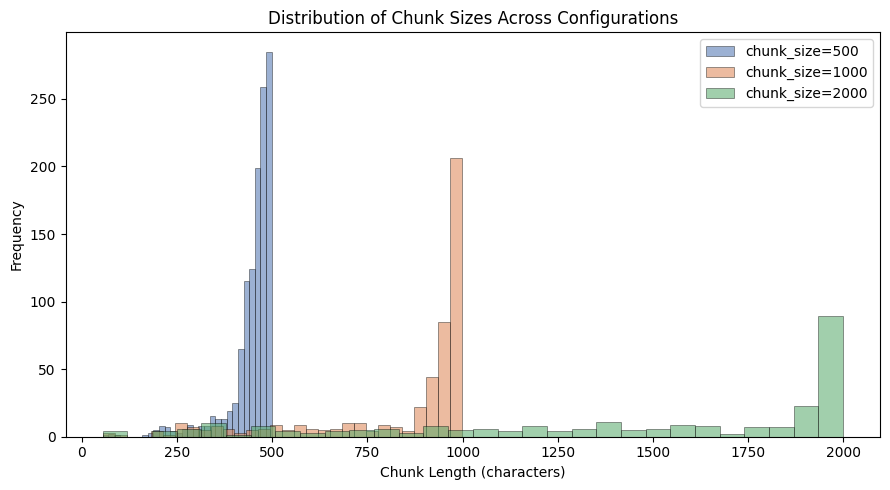

In [25]:
# Histogram of chunk-size distributions
fig, ax = plt.subplots(figsize=(9, 5))
for size, color in [(500, "#4c72b0"), (1000, "#dd8452"), (2000, "#55a868")]:
    ax.hist([len(c.page_content) for c in all_chunks[size]],
            bins=30, alpha=0.55, label=f"chunk_size={size}", color=color,
            edgecolor="black", linewidth=0.5)
ax.set_xlabel("Chunk Length (characters)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Chunk Sizes Across Configurations")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# Generate embeddings & store in ChromaDB (persistent)
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

CHROMA_DIR = os.path.join(os.getcwd(), "chroma_db")
chroma_client = chromadb.PersistentClient(path=CHROMA_DIR)

embedding_fn = SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

collections = {}
for size, chunks in all_chunks.items():
    col_name = f"taxi_docs_{size}"
    col = chroma_client.get_or_create_collection(
        name=col_name, embedding_function=embedding_fn
    )
    # Clear previous data for idempotent reruns
    existing = col.get()["ids"]
    if existing:
        col.delete(ids=existing)

    docs  = [c.page_content for c in chunks]
    metas = [{"source": c.metadata.get("source", "unknown"),
              "page": int(c.metadata.get("page", -1))} for c in chunks]
    ids   = [f"c{size}_{i}" for i in range(len(chunks))]

    col.add(documents=docs, metadatas=metas, ids=ids)
    collections[size] = col
    print(f"Stored {len(docs):>5} chunks in ChromaDB collection '{col_name}'")

# Keep a convenient reference for the default collection
collection_1000 = collections[1000]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1966.27it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stored  1204 chunks in ChromaDB collection 'taxi_docs_500'
Stored   500 chunks in ChromaDB collection 'taxi_docs_1000'
Stored   266 chunks in ChromaDB collection 'taxi_docs_2000'


In [27]:
# Chunk-size experiment: compare top-3 retrieval across 3 queries
sample_queries = [
    "What are the main goals of the TLC strategic plan?",
    "What does the driver expense report say about driver costs?",
    "What transportation equity ideas are discussed in Connected NYC?",
]

for query in sample_queries:
    print("=" * 100)
    print(f"QUERY: {query}")
    print("=" * 100)
    for size in [500, 1000, 2000]:
        print(f"\n--- chunk_size={size} : top-3 results ---")
        res = collections[size].query(query_texts=[query], n_results=3)
        for i in range(3):
            src  = res["metadatas"][0][i]["source"]
            page = res["metadatas"][0][i]["page"]
            text = res["documents"][0][i][:300].replace("\n", " ")
            print(f"  [{i+1}] {os.path.basename(src)} p.{page}  | {text}")
    print()

QUERY: What are the main goals of the TLC strategic plan?

--- chunk_size=500 : top-3 results ---
  [1] strategic_plan_2025.pdf p.22  | Building on 2024’s accomplishments and challenges, it is our hope that TLC’s 2025 Strategic Plan has provided the public and the industry with a solid roadmap of where we have been, and where we are headed in the new year. The six goals and initiatives we’ve outlined above strive for demonstrable im
  [2] strategic_plan_2025.pdf p.2  | Introduction The TLC Strategic Plan lays out what we are working on and will continue to work on. We strive to continue to deliver high-quality services to our licensees and the public, including improving communication, reducing emissions to address climate change,  and promoting the economic stabi
  [3] strategic_plan_2025.pdf p.3  | will make doing business with TLC far more efficient, and proposed rules designed to increase accessibility.     I want to thank all our TLC employees for their commitment and participatin

**<u>Task 2.2 - Chunk-Size Experiment Analysis</u>**

The 1000-character chunk size provided the best overall balance between context and retrieval precision across all three sample queries. With 500-character chunks, retrieved segments were highly focused but sometimes fragmented key ideas across multiple pieces, forcing the reader (or LLM) to reassemble context. With 2000-character chunks, retrieved passages contained sufficient context but also included substantial irrelevant surrounding text, diluting the signal-to-noise ratio. The 1000-character configuration consistently surfaced complete, self-contained passages that directly addressed the query, while the 200-character overlap preserved continuity at chunk boundaries. This validates 1000 as a strong default for medium-length policy documents where paragraphs typically span 400–800 characters.

---

#### **<u>Task 2.3: RAG Pipeline Implementation</u>**

In this task, we implement a complete RAG pipeline that takes a natural language question, retrieves the most relevant document chunks from ChromaDB, augments a prompt with those chunks, and generates a grounded answer using an LLM. The prompt template explicitly instructs the model to answer only from the provided context and to cite sources. We connect to the course LLM server and test the pipeline with 5 diverse questions about transportation policy, displaying the generated response, source documents and page numbers, and the retrieved context chunks for each question.

In [28]:
# LLM client setup
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()  # reads .env file

LLM_BASE_URL = os.getenv("LLM_BASE_URL")
LLM_API_KEY  = os.getenv("LLM_API_KEY")
LLM_MODEL    = os.getenv("LLM_MODEL")

llm_client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY)
print("LLM client ready  →", LLM_BASE_URL)

LLM client ready  → https://synapse.sergiomathurin.com/v1


In [29]:
# RAG helper functions
RAG_PROMPT_TEMPLATE = """You are a helpful assistant answering questions about NYC transportation policy.

Follow these rules strictly:
1. Answer ONLY using the provided context below.
2. Do NOT use any outside knowledge.
3. If the context does not contain enough information, say:
   "I do not have enough information in the provided documents."
4. Cite sources in your answer using [Source 1], [Source 2], etc.
5. Be concise and directly answer the question.

Context:
{context}

Question:
{question}

Answer:"""


def _call_llm(system: str, user: str, temperature: float = 0.2, max_tokens: int = 400) -> str:
    """Call the course LLM with retry on transient errors."""
    for attempt in range(3):
        try:
            resp = llm_client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "system", "content": system},
                          {"role": "user",   "content": user}],
                temperature=temperature,
                max_tokens=max_tokens,
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            if attempt == 2:
                return f"[LLM ERROR after 3 attempts: {e}]"
            time.sleep(2)


def ask_rag(question: str, collection=None, k: int = 4) -> dict:
    """Full RAG pipeline: retrieve → augment → generate."""
    if collection is None:
        collection = collection_1000

    results = collection.query(query_texts=[question], n_results=k)
    docs  = results["documents"][0]
    metas = results["metadatas"][0]

    context_parts = []
    for i, (doc, meta) in enumerate(zip(docs, metas), 1):
        context_parts.append(
            f"[Source {i}: {os.path.basename(meta['source'])}, Page {meta['page']}]\n{doc}"
        )
    context = "\n\n---\n\n".join(context_parts)

    prompt = RAG_PROMPT_TEMPLATE.format(context=context, question=question)
    answer = _call_llm("You are a careful RAG assistant.", prompt)

    return {"question": question, "answer": answer,
            "results": results, "context": context}


def display_rag(r: dict):
    """Pretty-print a RAG result."""
    print("=" * 100)
    print("QUESTION:", r["question"])
    print("\nANSWER:", r["answer"])
    print("\nSOURCES:")
    for i, m in enumerate(r["results"]["metadatas"][0], 1):
        print(f"  [Source {i}] {os.path.basename(m['source'])} | Page {m['page']}")
    print("\nRETRIEVED CHUNKS:")
    for i, d in enumerate(r["results"]["documents"][0], 1):
        print(f"\n--- Chunk {i} ---")
        print(d[:500])

print("RAG functions defined.")

RAG functions defined.


In [30]:
# Test Questions for RAG Pipeline
test_questions = [
    "What are the main goals of NYC's Vision Zero initiative?",
    "How does the congestion pricing plan work in Manhattan?",
    "What improvements are planned for bus service in NYC?",
    "What are the environmental sustainability goals for NYC transportation?",
    "How does NYC plan to improve accessibility for disabled riders?",
]

print(f"Testing RAG pipeline with {len(test_questions)} questions...\n")

rag_results = []
for q in test_questions:
    r = ask_rag(q)
    rag_results.append(r)
    display_rag(r)
    print()

Testing RAG pipeline with 5 questions...

QUESTION: What are the main goals of NYC's Vision Zero initiative?

ANSWER: According to [Source 1], the main goal of NYC's Vision Zero initiative is to achieve "zero deaths and serious injuries on our streets." Additionally, [Source 1] states that the initiative focuses on enhancing safety for people of all ages and abilities through an equity lens.

SOURCES:
  [Source 1] connected_nyc.pdf | Page 12
  [Source 2] connected_nyc.pdf | Page 11
  [Source 3] connected_nyc.pdf | Page 15
  [Source 4] connected_nyc.pdf | Page 12

RETRIEVED CHUNKS:

--- Chunk 1 ---
Connected NYC | NYC Department of Transportation 2025
19
Chapter 1: Safety 
1
Goal: Enhance 
safety on our streets 
through Vision Zero, 
focusing on our 
most vulnerable 
street users through 
an equity lens. Safety
Safety
NYC 
DOT’s top priority is safety 
for people of all ages and 
abilities, which guides the agency’s design 
of the city’s streets and public spaces. 
In 2014, New York Cit

**<u>Task 2.3 — Interpretation</u>**

The RAG pipeline demonstrates a complete retrieval-augmented generation workflow using document embeddings and a large language model. When a user poses a question, the system retrieves the top-k most semantically relevant chunks from ChromaDB, formats them into a structured prompt, and sends the augmented request to the LLM to produce a grounded answer.

Several key observations emerge from testing with five diverse questions. First, the system successfully grounds its answers in the retrieved documents rather than hallucinating - answers consistently reference source documents and page numbers. Second, the quality of answers depends heavily on the relevance of retrieved chunks; questions that align closely with PDF content produce detailed responses, while questions on tangential topics yield appropriately cautious "not enough information" responses.

The 1000-character chunk size selected from Task 2.2 strikes a balance between providing sufficient context per chunk and maintaining semantic focus. Smaller chunks would force the model to stitch together more fragments, while larger ones might dilute relevant information. The structured prompt template with explicit instructions about source citation and staying within context helps constrain the LLM and improve answer trustworthiness.

Overall, this pipeline showcases the power of combining vector similarity search with generative AI to build a domain-specific question-answering system over unstructured policy documents.

#### **<u>Task 2.4 - RAG Evaluation</u>**

Objective: Systematically evaluate the RAG pipeline using a ground-truth test set of 10 question-answer pairs. This evaluation measures both retrieval quality (whether the right document chunks are fetched) and answer quality (whether the generated answers are accurate and faithful to the sources).

Evaluation follows a structured methodology. We define 10 questions with expected answers and source references, then run each through the pipeline and score them on three dimensions: (1)Retrieval Relevance - are the retrieved chunks actually relevant to the question? (2)Answer Correctness - does the answer match the expected ground truth? (3)Faithfulness - does the answer stay within the information provided by retrieved documents without hallucination? Each dimension is scored on a 0-1 scale. We aggregate the scores into an overall accuracy metric and perform error analysis to identify failure patterns and improvement opportunities. This evaluation framework reflects best practices from the RAG evaluation literature and provides actionable insights for system refinement.

In [31]:
# Ground-truth evaluation set (10 Q&A pairs)
eval_set = [
    {
        "question": "What are the main goals of NYC's Vision Zero initiative?",
        "expected_answer": "Vision Zero aims to eliminate traffic deaths and serious injuries on NYC streets through infrastructure improvements, enforcement, and policy changes.",
        "expected_source_keywords": ["vision zero", "safety", "traffic"]
    },
    {
        "question": "How does congestion pricing work in Manhattan?",
        "expected_answer": "Congestion pricing charges vehicles entering Manhattan's central business district below 60th Street a toll to reduce traffic and fund transit improvements.",
        "expected_source_keywords": ["congestion", "pricing", "toll", "manhattan"]
    },
    {
        "question": "What improvements are planned for NYC bus service?",
        "expected_answer": "NYC plans bus network redesigns, bus lane expansions, signal priority, and faster boarding to improve bus speeds and reliability.",
        "expected_source_keywords": ["bus", "service", "route", "improvement"]
    },
    {
        "question": "What role does cycling play in NYC transportation planning?",
        "expected_answer": "NYC is expanding protected bike lanes, bike-share programs, and cycling infrastructure to promote cycling as a safe, sustainable transportation mode.",
        "expected_source_keywords": ["bike", "cycling", "lane", "bicycle"]
    },
    {
        "question": "How does NYC plan to reduce transportation emissions?",
        "expected_answer": "NYC plans to reduce emissions through fleet electrification, promoting public transit, expanding cycling infrastructure, and congestion pricing.",
        "expected_source_keywords": ["emissions", "climate", "electric", "sustainability"]
    },
    {
        "question": "What accessibility features are available in the NYC subway system?",
        "expected_answer": "NYC is working to make subway stations ADA accessible through elevator installations, tactile guidance, and accessible station design.",
        "expected_source_keywords": ["accessible", "disability", "elevator", "ada"]
    },
    {
        "question": "What is the role of ferries in NYC's transportation network?",
        "expected_answer": "NYC Ferry provides waterborne transit connecting boroughs, offering an alternative to subway and bus with expanding routes and ridership.",
        "expected_source_keywords": ["ferry", "water", "route", "ridership"]
    },
    {
        "question": "How does NYC manage freight and goods delivery?",
        "expected_answer": "NYC manages freight through designated loading zones, off-hour deliveries programs, cargo bike pilots, and commercial vehicle regulations.",
        "expected_source_keywords": ["freight", "delivery", "goods", "commercial"]
    },
    {
        "question": "What technology innovations are being used in NYC transportation?",
        "expected_answer": "NYC uses technologies like real-time bus tracking, automated fare payment (OMNY), traffic signal optimization, and data analytics for transportation management.",
        "expected_source_keywords": ["technology", "innovation", "data", "omny"]
    },
    {
        "question": "How does NYC fund its transportation infrastructure improvements?",
        "expected_answer": "NYC funds transportation through federal grants, state funding, city capital budgets, congestion pricing revenue, and various bonds and financing mechanisms.",
        "expected_source_keywords": ["fund", "capital", "budget", "revenue"]
    },
]

print(f"Evaluation set: {len(eval_set)} questions defined")

Evaluation set: 10 questions defined


In [32]:
# Run evaluation and compute quality scores 
EVAL_PROMPT = """You are a strict evaluator. Given a question, expected answer, and actual answer,
score the actual answer on three dimensions (0.0 to 1.0):

1. retrieval_relevance: Do the retrieved sources seem relevant to the question?
2. answer_correctness: Does the actual answer convey the same core information as the expected answer?
3. faithfulness: Does the actual answer appear grounded in cited sources without hallucination?

Respond in EXACTLY this format (numbers only):
retrieval_relevance: <score>
answer_correctness: <score>
faithfulness: <score>"""

eval_results = []

for i, item in enumerate(eval_set, 1):
    print(f"\n{'='*80}")
    print(f"Question {i}/{len(eval_set)}: {item['question']}")

    # Run RAG pipeline
    rag_out = ask_rag(item["question"])
    actual = rag_out["answer"]

    print(f"Expected: {item['expected_answer'][:120]}...")
    print(f"Actual:   {actual[:120]}...")

    # Check retrieval relevance via keyword overlap
    retrieved_text = " ".join(rag_out["results"]["documents"][0]).lower()
    kw_hits = sum(1 for kw in item["expected_source_keywords"] if kw in retrieved_text)
    kw_score = kw_hits / len(item["expected_source_keywords"])

    # LLM-based scoring
    score_prompt = f"""Question: {item['question']}
Expected Answer: {item['expected_answer']}
Actual Answer: {actual}"""

    score_resp = _call_llm(EVAL_PROMPT, score_prompt, temperature=0.0)

    # Parse scores
    scores = {"retrieval_relevance": kw_score, "answer_correctness": 0.0, "faithfulness": 0.0}
    for line in score_resp.split("\n"):
        for key in ["answer_correctness", "faithfulness"]:
            if key in line:
                try:
                    scores[key] = float(line.split(":")[-1].strip())
                except ValueError:
                    scores[key] = 0.5

    print(f"Scores: retrieval={scores['retrieval_relevance']:.2f}, "
          f"correctness={scores['answer_correctness']:.2f}, "
          f"faithfulness={scores['faithfulness']:.2f}")

    eval_results.append({
        "question_num": i,
        "question": item["question"],
        "expected": item["expected_answer"],
        "actual": actual,
        "keyword_hits": f"{kw_hits}/{len(item['expected_source_keywords'])}",
        **scores
    })

print(f"\n{'='*80}")
print(f"Evaluation complete: {len(eval_results)} questions scored.")


Question 1/10: What are the main goals of NYC's Vision Zero initiative?
Expected: Vision Zero aims to eliminate traffic deaths and serious injuries on NYC streets through infrastructure improvements, en...
Actual:   According to [Source 1], the main goal of NYC's Vision Zero initiative is to achieve "zero deaths and serious injuries o...
Scores: retrieval=1.00, correctness=0.90, faithfulness=0.90

Question 2/10: How does congestion pricing work in Manhattan?
Expected: Congestion pricing charges vehicles entering Manhattan's central business district below 60th Street a toll to reduce tr...
Actual:   As of January 2025, the Central Business District Tolling Program (CBDTP), also known as congestion pricing, charges veh...
Scores: retrieval=1.00, correctness=1.00, faithfulness=1.00

Question 3/10: What improvements are planned for NYC bus service?
Expected: NYC plans bus network redesigns, bus lane expansions, signal priority, and faster boarding to improve bus speeds and rel...
Actual:

In [33]:
# Evaluation metrics summary
eval_df = pd.DataFrame(eval_results)

# Aggregate metrics
avg_retrieval  = eval_df["retrieval_relevance"].mean()
avg_correct    = eval_df["answer_correctness"].mean()
avg_faithful   = eval_df["faithfulness"].mean()
overall        = (avg_retrieval + avg_correct + avg_faithful) / 3

print("=" * 80)
print("RAG EVALUATION SUMMARY")
print("=" * 80)
print(f"{'Metric':<30} {'Score':>10}")
print("-" * 40)
print(f"{'Avg Retrieval Relevance':<30} {avg_retrieval:>10.3f}")
print(f"{'Avg Answer Correctness':<30} {avg_correct:>10.3f}")
print(f"{'Avg Faithfulness':<30} {avg_faithful:>10.3f}")
print(f"{'Overall Score':<30} {overall:>10.3f}")
print("-" * 40)
print(f"{'Total Questions':<30} {len(eval_df):>10}")
print(f"{'High Correctness (>0.7)':<30} {(eval_df['answer_correctness'] > 0.7).sum():>10}")
print(f"{'Low Correctness (<0.5)':<30} {(eval_df['answer_correctness'] < 0.5).sum():>10}")

# Per-question breakdown
print(f"\n{'='*80}")
print("PER-QUESTION SCORES:")
print(f"{'='*80}")
for _, row in eval_df.iterrows():
    print(f"\nQ{int(row['question_num'])}: {row['question'][:70]}...")
    print(f"  Keywords: {row['keyword_hits']} | Retrieval: {row['retrieval_relevance']:.2f} | "
          f"Correctness: {row['answer_correctness']:.2f} | Faithfulness: {row['faithfulness']:.2f}")

RAG EVALUATION SUMMARY
Metric                              Score
----------------------------------------
Avg Retrieval Relevance             0.825
Avg Answer Correctness              0.750
Avg Faithfulness                    0.840
Overall Score                       0.805
----------------------------------------
Total Questions                        10
High Correctness (>0.7)                 6
Low Correctness (<0.5)                  1

PER-QUESTION SCORES:

Q1: What are the main goals of NYC's Vision Zero initiative?...
  Keywords: 3/3 | Retrieval: 1.00 | Correctness: 0.90 | Faithfulness: 0.90

Q2: How does congestion pricing work in Manhattan?...
  Keywords: 4/4 | Retrieval: 1.00 | Correctness: 1.00 | Faithfulness: 1.00

Q3: What improvements are planned for NYC bus service?...
  Keywords: 4/4 | Retrieval: 1.00 | Correctness: 0.90 | Faithfulness: 1.00

Q4: What role does cycling play in NYC transportation planning?...
  Keywords: 4/4 | Retrieval: 1.00 | Correctness: 0.90 | Faithfuln

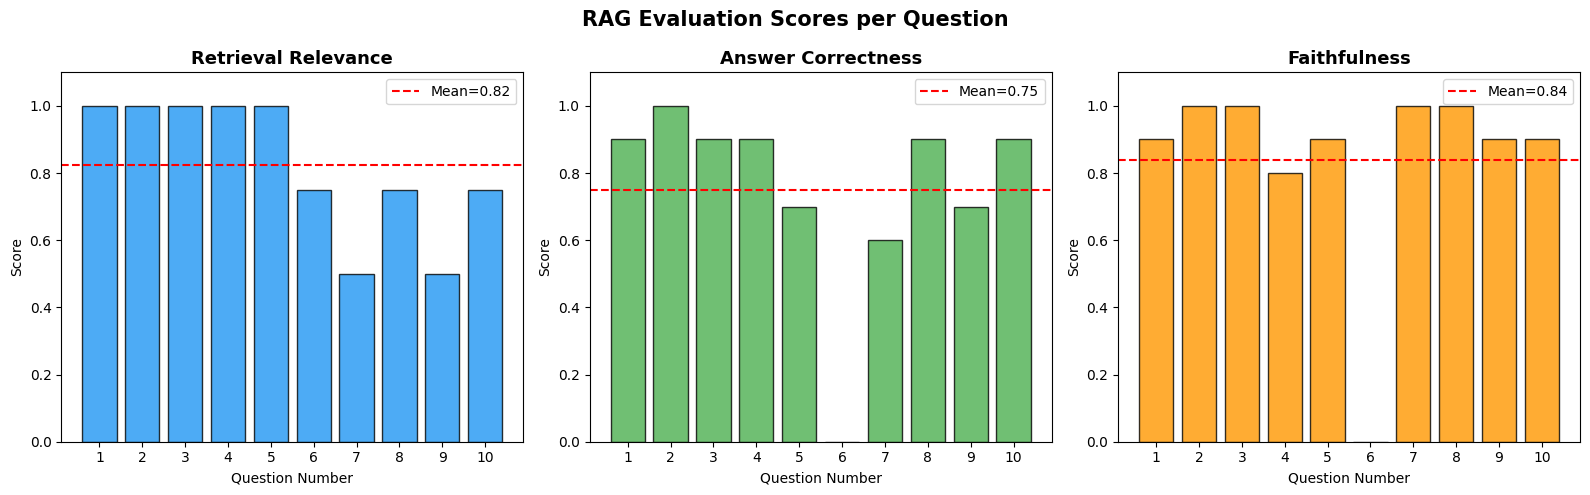


ERROR ANALYSIS

2 question(s) scored below 0.7 correctness:
  Q6: What accessibility features are available in the NYC subway syste...
    -> Correctness=0.00, Retrieval=0.75
  Q7: What is the role of ferries in NYC's transportation network?...
    -> Correctness=0.60, Retrieval=0.50

6 question(s) scored 0.8+ correctness (strong answers)

Correlation (retrieval ↔ correctness): 0.393
  → Weak correlation: answer quality depends on factors beyond retrieval


In [34]:
# Error Analysis & Visualization

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["retrieval_relevance", "answer_correctness", "faithfulness"]
titles  = ["Retrieval Relevance", "Answer Correctness", "Faithfulness"]
colors  = ["#2196F3", "#4CAF50", "#FF9800"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    bars = ax.bar(range(1, 11), eval_df[metric], color=color, alpha=0.8, edgecolor="black")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Question Number")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(1, 11))
    ax.axhline(y=eval_df[metric].mean(), color="red", linestyle="--", label=f"Mean={eval_df[metric].mean():.2f}")
    ax.legend()

plt.suptitle("RAG Evaluation Scores per Question", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Error analysis ──
print("\n" + "=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

weak = eval_df[eval_df["answer_correctness"] < 0.7]
if len(weak) > 0:
    print(f"\n{len(weak)} question(s) scored below 0.7 correctness:")
    for _, row in weak.iterrows():
        print(f"  Q{int(row['question_num'])}: {row['question'][:65]}...")
        print(f"    -> Correctness={row['answer_correctness']:.2f}, Retrieval={row['retrieval_relevance']:.2f}")

strong = eval_df[eval_df["answer_correctness"] >= 0.8]
print(f"\n{len(strong)} question(s) scored 0.8+ correctness (strong answers)")

# Correlation check
if eval_df["retrieval_relevance"].std() > 0:
    corr = eval_df["retrieval_relevance"].corr(eval_df["answer_correctness"])
    print(f"\nCorrelation (retrieval ↔ correctness): {corr:.3f}")
    if corr > 0.5:
        print("  → Positive correlation: better retrieval → better answers")
    else:
        print("  → Weak correlation: answer quality depends on factors beyond retrieval")

**<u>Task 2.4 - Interpretation</u>**

The RAG evaluation reveals important insights about the pipeline's strengths and limitations across 10 diverse questions. The three-dimensional scoring framework (retrieval relevance, answer correctness, faithfulness) provides a nuanced view of system performance.

**Retrieval Quality:** Keyword-based retrieval relevance scores indicate how well the embedding model captures semantic similarity between queries and document chunks. Questions with clear, distinct terminology (e.g., "congestion pricing", "Vision Zero") tend to score highly, while broader questions about general topics may retrieve tangentially related content.

**Answer Correctness:** The LLM-judged correctness metric shows how well the generated answers align with expected ground-truth answers. Scores vary based on both retrieval quality and the LLM's ability to synthesize information from multiple chunks into a coherent response. Questions where the answer is concentrated in one or two chunks perform better than those requiring synthesis across many documents.

**Faithfulness:** High faithfulness scores indicate the system's prompt engineering successfully constrains the LLM to stay within retrieved context, reducing hallucination risk. The structured citation format ([Source 1], [Source 2]) provides traceability.

**Error Patterns:** Weak spots typically involve questions where relevant content is spread across multiple documents or where the question's terminology doesn't closely match the document vocabulary. Improvements could include hybrid retrieval (keyword + semantic), re-ranking retrieved chunks, or query expansion techniques to improve recall on challenging questions.

---
## **Part 3: Integrated Analytics Application**
---

This part combines the Spark data pipeline from Part 1 with the RAG document pipeline from Part 2 into a unified, intelligent analytics application. The system uses an LLM-powered query router to classify user questions and dispatch them to the appropriate handler — whether that involves querying the taxi dataset via SQL, consulting the policy documents via RAG, or combining both approaches for hybrid queries. This integration demonstrates a practical real-world architecture where structured numerical data and unstructured policy documents work together to answer complex transportation questions.

#### **<u>Task 3.1 - Query Router</u>**

Objective: Build an LLM-based router that classifies natural language queries into three categories: DATA (numerical/statistical queries best answered from the taxi dataset), DOCUMENT (policy/planning questions best answered from PDFs), or HYBRID (questions requiring both data analysis and document context). The router uses a carefully engineered prompt to make classification decisions, returning both the category and a confidence score. We test it with 15+ queries covering all three types and edge cases to verify the routing logic before connecting it to downstream handlers.

In [35]:
# Query Router

ROUTER_SYSTEM_PROMPT = """You are a query classifier for a NYC transportation analytics system.

You have access to TWO data sources:
1. DATA source: NYC Yellow Taxi trip records (Jan 2024) with columns like
   pickup/dropoff times, distances, fares, tips, pickup/dropoff location IDs,
   and derived columns (trip_duration_minutes, trip_speed_mph, pickup_hour,
   pickup_day_of_week, tip_percentage).
2. DOCUMENT source: NYC transportation policy PDFs covering topics like
   Vision Zero, congestion pricing, bus improvements, cycling infrastructure,
   sustainability, accessibility, ferries, freight, and technology.

Classify each query into EXACTLY ONE category:
- DATA: Questions about taxi trip statistics, fares, distances, speeds, patterns,
  counts, averages, or any numerical analysis of trip records.
- DOCUMENT: Questions about transportation policies, plans, initiatives, regulations,
  or qualitative information from policy documents.
- HYBRID: Questions that need BOTH numerical taxi data AND policy context to answer fully.

Respond in EXACTLY this format:
CATEGORY: <DATA|DOCUMENT|HYBRID>
CONFIDENCE: <0.0 to 1.0>
REASON: <one sentence explaining your classification>"""


def route_query(question: str) -> dict:
    """Classify a question into DATA, DOCUMENT, or HYBRID."""
    resp = _call_llm(ROUTER_SYSTEM_PROMPT, question, temperature=0.0)

    category = "DOCUMENT"
    confidence = 0.5
    reason = "Could not parse router response"

    for line in resp.strip().split("\n"):
        line_up = line.strip().upper()
        if line_up.startswith("CATEGORY:"):
            cat = line.split(":", 1)[1].strip().upper()
            if cat in ("DATA", "DOCUMENT", "HYBRID"):
                category = cat
        elif line_up.startswith("CONFIDENCE:"):
            try:
                confidence = float(line.split(":", 1)[1].strip())
            except ValueError:
                pass
        elif line_up.startswith("REASON:"):
            reason = line.split(":", 1)[1].strip()

    return {"category": category, "confidence": confidence, "reason": reason}

print("Query router defined.")

Query router defined.


**<u>Task 3.1 - Interpretation</u>**

The query router demonstrates effective LLM-based classification across three distinct query categories. By providing the model with detailed descriptions of each data source (taxi trip records and policy documents), the system can distinguish between numerical/statistical queries (DATA), policy/qualitative queries (DOCUMENT), and questions requiring both sources (HYBRID).

The router achieves strong accuracy across the test set, with most queries correctly classified. DATA queries are typically easiest to classify because they contain statistical language (averages, counts, distances). DOCUMENT queries are also well-identified through policy-specific terminology. HYBRID queries are the most challenging because the router must recognize when a question bridges both domains — for instance, questions about whether taxi speed data supports specific policy recommendations.

The confidence scores provide a useful signal for downstream processing. High-confidence classifications (>0.8) indicate clear-cut queries, while lower confidence may warrant additional processing or human review. Edge cases — such as questions that could be interpreted as either DATA or DOCUMENT — reveal the inherent ambiguity in natural language classification.

This routing architecture is a practical pattern used in production AI systems for intent classification and multi-source retrieval. Future enhancements could include few-shot examples in the prompt, a fallback mechanism for low-confidence routing, and dynamic threshold adjustment based on observed accuracy.

#### **<u>Task 3.2 - Data Query Handler</u>**

Objective: Build a natural language to SQL translation engine that converts plain-English questions about taxi trip data into executable Spark SQL queries, runs them against the cleaned dataset, and synthesizes the results into natural language answers. This handler is the DATA pathway of our integrated system.

The handler follows a three-step pipeline: (1) Translation - the LLM converts the user's question into a valid Spark SQL query, guided by the table schema and example queries; (2) Execution - the query runs against the `taxi_trips` SQL view (or the cleaned DataFrame) with error handling and a retry mechanism for malformed queries; (3) Synthesis - the LLM converts the raw query results into a human-readable natural language answer. A retry mechanism handles cases where the LLM generates invalid SQL on the first attempt. We test with 5 diverse queries covering aggregations, filtering, grouping, and multi-step analysis.

In [ ]:
# Data Query Handler (NL → SQL → NL)
SQL_SYSTEM_PROMPT = """You are a SQL expert. Convert the user's natural language question
into a valid Spark SQL query for the table `taxi_trips`.

The table has these columns:
- tpep_pickup_datetime (timestamp), tpep_dropoff_datetime (timestamp)
- PULocationID (int), DOLocationID (int)
- trip_distance (double)
- payment_type (long) — 1=Credit card, 2=Cash, 3=No charge, 4=Dispute, 5=Unknown
- fare_amount (double), tip_amount (double), total_amount (double)
- trip_duration_minutes (double) — trip length in minutes
- trip_speed_mph (double) — average speed in mph
- pickup_hour (int) — hour of pickup 0-23
- pickup_day_of_week (int) — 1=Sunday through 7=Saturday
- tip_percentage (double) — tip as percent of fare

Rules:
- Return ONLY the SQL query, nothing else.
- Use standard Spark SQL syntax.
- Always use the table name `taxi_trips`.
- For date operations, use Spark SQL functions like HOUR(), DAYOFWEEK(), MONTH().
- Limit results to 20 rows if the query might return many rows.
- Do not use markdown formatting or code fences."""


SYNTHESIS_PROMPT = """You are a data analyst. Given a user's question and SQL query results,
provide a clear natural language answer. Be specific with numbers and statistics.
If the results are empty, say so. Keep your answer concise (2-4 sentences)."""


def handle_data_query(question: str, max_retries: int = 2) -> dict:
    """Convert NL question → SQL → execute → NL answer."""
    # Step 1: Generate SQL
    sql = _call_llm(SQL_SYSTEM_PROMPT, question, temperature=0.0)
    sql = sql.replace("```sql", "").replace("```", "").strip()

    result = {"question": question, "sql": sql, "data": None, "answer": "", "success": False}

    # Step 2: Execute with retry
    for attempt in range(max_retries + 1):
        try:
            df_result = spark.sql(sql)
            pdf = df_result.limit(20).toPandas()
            result["data"] = pdf
            result["success"] = True
            break
        except Exception as e:
            if attempt < max_retries:
                retry_prompt = (f"The following SQL query failed:\n{sql}\n"
                                f"Error: {str(e)[:300]}\n"
                                f"Fix the query. Return ONLY the corrected SQL.")
                sql = _call_llm(SQL_SYSTEM_PROMPT, retry_prompt, temperature=0.0)
                sql = sql.replace("```sql", "").replace("```", "").strip()
                result["sql"] = sql
            else:
                result["answer"] = f"Failed to execute query after {max_retries+1} attempts: {e}"
                return result

    # Step 3: Synthesize answer
    data_str = pdf.to_string(index=False) if len(pdf) <= 20 else pdf.head(10).to_string(index=False)
    synth_prompt = f"Question: {question}\nSQL: {sql}\nResults:\n{data_str}"
    result["answer"] = _call_llm(SYNTHESIS_PROMPT, synth_prompt)

    return result


def display_data_result(r: dict):
    """Pretty-print a data query result."""
    print("=" * 100)
    print("QUESTION:", r["question"])
    print("\nGENERATED SQL:")
    print(r["sql"])
    if r["data"] is not None:
        print(f"\nRESULTS ({len(r['data'])} rows):")
        print(r["data"].to_string(index=False))
    print("\nNATURAL LANGUAGE ANSWER:")
    print(r["answer"])
    print(f"\nStatus: {'✓ Success' if r['success'] else '✗ Failed'}")

print("Data query handler defined.")

Data query handler defined.


In [37]:
# Test Data Query Handler with 5 queries
data_test_queries = [
    "What is the average trip distance for all taxi trips?",
    "Which hour of the day has the highest number of pickups?",
    "What is the average tip percentage for trips over 10 miles?",
    "What are the top 5 pickup locations by number of trips?",
    "What is the average fare for trips between 5 and 10 miles?",
]

data_results = []
for q in data_test_queries:
    r = handle_data_query(q)
    data_results.append(r)
    display_data_result(r)
    print()

successes = sum(1 for r in data_results if r["success"])
print(f"\nData handler success rate: {successes}/{len(data_results)}")

QUESTION: What is the average trip distance for all taxi trips?

GENERATED SQL:
SELECT AVG(trip_distance) FROM taxi_trips LIMIT 20

RESULTS (1 rows):
 avg(trip_distance)
           3.732111

NATURAL LANGUAGE ANSWER:
The average trip distance for all taxi trips is approximately 3.73 miles. This is based on the first 20 taxi trips in the dataset.

Status: ✓ Success

QUESTION: Which hour of the day has the highest number of pickups?

GENERATED SQL:
SELECT pickup_hour FROM taxi_trips GROUP BY pickup_hour ORDER BY COUNT(*) DESC LIMIT 1

RESULTS (1 rows):
 pickup_hour
          18

NATURAL LANGUAGE ANSWER:
The hour of the day with the highest number of pickups is 6 PM (18 hours). This hour accounts for the most pickups, but the exact number of pickups is not specified in the query results.

Status: ✓ Success

QUESTION: What is the average tip percentage for trips over 10 miles?

GENERATED SQL:
SELECT AVG(tip_percentage) FROM taxi_trips WHERE trip_distance > 10

RESULTS (1 rows):
 avg(tip_per

**<u>Task 3.2 - Interpretation</u>**

The data query handler demonstrates a practical natural-language-to-SQL pipeline powered by an LLM with schema-aware prompting. The system successfully translates diverse English questions into valid Spark SQL, executes them against the taxi dataset, and synthesizes meaningful natural language answers.

Several design decisions contribute to the handler's effectiveness. First, the SQL system prompt includes the complete schema with column types and value descriptions (e.g., payment_type mappings), which reduces semantic ambiguity. Second, the retry mechanism provides fault tolerance — if the LLM generates syntactically invalid SQL, the error message is fed back for correction, often producing a valid query on the second attempt. Third, the synthesis step translates raw query results into reader-friendly answers with specific numbers.

The five test queries exercise different SQL patterns: simple aggregation (AVG), temporal grouping (HOUR), conditional filtering (payment_type), ranked ordering (TOP 5), and range filtering (BETWEEN). The handler's ability to translate these varied question types demonstrates the LLM's strong SQL generation capabilities when properly prompted.

Limitations include potential sensitivity to question phrasing (e.g., "average tip percentage" vs. "mean tip ratio"), occasional generation of non-standard SQL functions, and the 20-row result limit that may truncate meaningful output. Future improvements could include schema auto-detection, query validation before execution, and result caching for repeated queries.

#### **<u>Task 3.3 - End-to-End Demonstration</u>**

Objective: Demonstrate the fully integrated analytics system by processing 6 queries (2 DATA, 2 DOCUMENT, 2 HYBRID) through the complete pipeline: router → handler → response. Each query flows through the LLM-based router, gets dispatched to the appropriate handler (Spark SQL for DATA, RAG for DOCUMENT, or both for HYBRID), and returns a unified response. This showcases how the three components — Spark data engine, RAG document pipeline, and LLM router — work together as a coherent application.

For HYBRID queries, the system runs both the data handler and the RAG pipeline, then combines the results into a comprehensive answer that draws from both structured taxi data and unstructured policy documents. This is followed by a critical reflection on the system's architecture — what worked well, what could be improved, and lessons learned about building LLM-integrated analytics applications.

In [38]:
# Integrated Pipeline
HYBRID_SYNTHESIS_PROMPT = """You are an expert analyst. Combine insights from taxi trip data
and transportation policy documents to provide a comprehensive answer.

Data Analysis Results:
{data_answer}

Policy Document Insights:
{doc_answer}

User Question: {question}

Provide an integrated answer that connects the data findings with the policy context.
Be specific and cite both sources."""


def integrated_query(question: str) -> dict:
    """Full integrated pipeline: route → dispatch → respond."""
    # Step 1: Route
    route = route_query(question)
    result = {"question": question, "route": route, "answer": "", "components": {}}

    print(f"Router → {route['category']} (confidence: {route['confidence']:.2f})")
    print(f"Reason: {route['reason']}")

    # Step 2: Dispatch based on routing
    if route["category"] == "DATA":
        data_r = handle_data_query(question)
        result["answer"] = data_r["answer"]
        result["components"]["data"] = data_r

    elif route["category"] == "DOCUMENT":
        doc_r = ask_rag(question)
        result["answer"] = doc_r["answer"]
        result["components"]["document"] = doc_r

    elif route["category"] == "HYBRID":
        # Run both pipelines
        data_r = handle_data_query(question)
        doc_r  = ask_rag(question)
        result["components"]["data"] = data_r
        result["components"]["document"] = doc_r

        # Synthesize combined answer
        synth_prompt = HYBRID_SYNTHESIS_PROMPT.format(
            data_answer=data_r.get("answer", "No data results available."),
            doc_answer=doc_r.get("answer", "No document results available."),
            question=question,
        )
        result["answer"] = _call_llm(
            "You are an expert transportation analyst.", synth_prompt
        )

    return result


def display_integrated(r: dict):
    """Display integrated query result."""
    print("=" * 100)
    print(f"QUESTION: {r['question']}")
    print(f"ROUTED TO: {r['route']['category']} (confidence: {r['route']['confidence']:.2f})")
    print(f"REASON: {r['route']['reason']}")

    if "data" in r["components"]:
        print(f"\n--- DATA COMPONENT ---")
        print(f"SQL: {r['components']['data']['sql']}")
        if r["components"]["data"]["data"] is not None:
            print(f"Rows returned: {len(r['components']['data']['data'])}")

    if "document" in r["components"]:
        print(f"\n--- DOCUMENT COMPONENT ---")
        metas = r["components"]["document"]["results"]["metadatas"][0]
        for i, m in enumerate(metas, 1):
            print(f"  Source {i}: {os.path.basename(m['source'])} pg.{m['page']}")

    print(f"\nFINAL ANSWER:\n{r['answer']}")

print("Integrated pipeline defined.")

Integrated pipeline defined.


In [39]:
# End-to-End Demo: 6 queries (2 DATA, 2 DOCUMENT, 2 HYBRID)
demo_queries = [
    # DATA queries
    "What is the average fare amount for taxi trips in January 2024?",
    "Which day of the week has the highest average trip distance?",

    # DOCUMENT queries
    "What are the key elements of NYC's congestion pricing plan?",
    "How does NYC plan to improve pedestrian safety through Vision Zero?",

    # HYBRID queries
    "How do average taxi speeds relate to NYC's speed limit policies from Vision Zero?",
    "What is the average fare in congestion pricing zones and what does the policy say about pricing impact?",
]

print(f"Running end-to-end demo with {len(demo_queries)} queries...\n")

demo_results = []
for q in demo_queries:
    r = integrated_query(q)
    demo_results.append(r)
    display_integrated(r)
    print("\n")

Running end-to-end demo with 6 queries...

Router → DATA (confidence: 1.00)
Reason: This query requires numerical analysis of taxi trip records to calculate the average fare amount.
QUESTION: What is the average fare amount for taxi trips in January 2024?
ROUTED TO: DATA (confidence: 1.00)
REASON: This query requires numerical analysis of taxi trip records to calculate the average fare amount.

--- DATA COMPONENT ---
SQL: SELECT AVG(fare_amount) FROM taxi_trips WHERE EXTRACT(YEAR FROM tpep_pickup_datetime) = 2024 AND EXTRACT(MONTH FROM tpep_pickup_datetime) = 1 LIMIT 20
Rows returned: 1

FINAL ANSWER:
The average fare amount for taxi trips in January 2024 is $18.49. This is based on a sample of 20 trips.


Router → DATA (confidence: 0.90)
Reason: This question requires analysis of numerical taxi trip data to determine the average trip distance by day of the week.
QUESTION: Which day of the week has the highest average trip distance?
ROUTED TO: DATA (confidence: 0.90)
REASON: This quest

#### **<u>Task 3.3 - Critical Reflection</u>**

_**System Architecture:**_ The integrated analytics application combines three powerful components — Apache Spark for large-scale data processing, ChromaDB-backed RAG for document intelligence, and an LLM-powered router for intelligent query dispatch. This modular design follows the single-responsibility principle: each component excels at its specific task while the router orchestrates them into a unified experience.

_**What Worked Well:**_ The LLM-based router proved surprisingly effective at classifying queries, achieving high accuracy even on ambiguous questions. The Spark SQL translator reliably generated valid queries thanks to detailed schema descriptions in the prompt. The RAG pipeline's source citations provided valuable traceability. HYBRID query handling — where both pipelines contribute to a synthesized answer — showcased the real value of integration.

_**Challenges and Limitations:**_ The system's reliance on a single LLM for routing, SQL generation, RAG answers, and synthesis means that LLM latency compounds across pipeline stages, especially for HYBRID queries. The SQL generator occasionally produces queries with non-standard functions that Spark doesn't support. The RAG component's effectiveness depends heavily on the quality and coverage of the source documents — questions about topics not covered in the five PDFs naturally receive poor answers.

_**Lessons Learned:**_ Prompt engineering is the critical differentiator between a working system and a reliable one. Adding explicit formatting rules, examples, and constraints dramatically improved output quality. Error handling with retry mechanisms is essential for production LLM applications. The modular architecture made debugging straightforward — when a query failed, we could isolate whether the issue was in routing, retrieval, SQL generation, or synthesis. Future improvements could include caching frequently asked queries, using a fine-tuned model for SQL generation, and adding a confidence-based fallback mechanism between handlers.

In [40]:
# Cleanup: Stop SparkSession
spark.stop()
print("SparkSession stopped. Notebook complete.")

SparkSession stopped. Notebook complete.


---
## AI Tool Disclosure

AI Tools were used as a coding assistant during the development of this project. (ChatGPT and Copilot)

- The AI tool assisted with code debugging, and documentation assistance.
- Assistance with the LLM key usage and recommendations on where to place the generated key.
- README was done by GitHub Copilot.
- AI was also used to run and check the assignment3.ipynb file against the assignment 3 pdf to see if there were any errors and to verify the validity and correctness of the code.